# Task 2 — Trends, and the spaghetti problem
Dataset: `gapminder.csv`, 142 countries x 12 years (1952-2007), no missing values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (colour-blind safe, same as the lecture notebook) ----
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.labelsize": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "legend.fontsize": 10, "lines.linewidth": 2, "font.size": 11,
    "savefig.dpi": 150, "savefig.bbox": "tight",
})

def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)

def note(ax, text, y=-0.2):
    """Footnote under a chart - used to say what was excluded."""
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

In [2]:
g = pd.read_csv(DATA / "gapminder.csv")
print(g.shape, "| countries:", g.country.nunique(), "| missing values:", int(g.isna().sum().sum()))
g.head()

(1704, 6) | countries: 142 | missing values: 0


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333.0,779.445314
1,Afghanistan,Asia,1957,30.332,9240934.0,820.853030
2,Afghanistan,Asia,1962,31.997,10267083.0,853.100710
3,Afghanistan,Asia,1967,34.020,11537966.0,836.197138
4,Afghanistan,Asia,1972,36.088,13079460.0,739.981106


## 1. The messy chart on purpose
One line per country, all 142, with a legend.

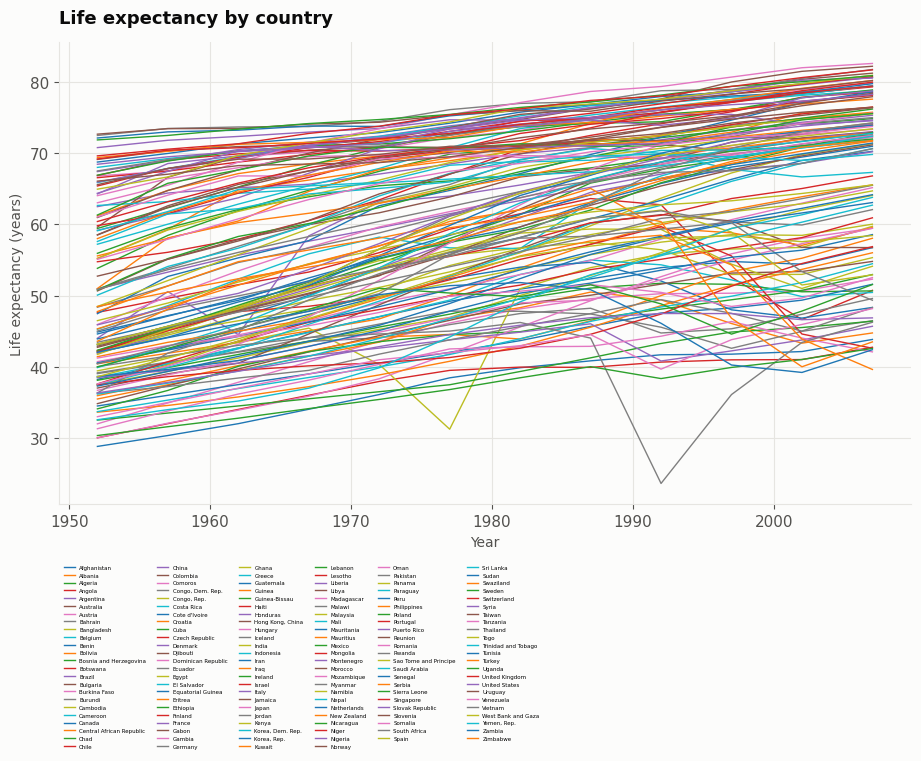

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
for country, d in g.groupby("country"):
    ax.plot(d.year, d.lifeExp, linewidth=1, label=country)
ax.set_title("Life expectancy by country")
ax.set_xlabel("Year"); ax.set_ylabel("Life expectancy (years)")
ax.legend(ncol=6, fontsize=4, loc="upper left", bbox_to_anchor=(0, -0.12))
save(fig, "t2_1_spaghetti")
plt.show()

This is about as bad as a chart gets, and on purpose:
- Title just names the axes, no actual finding.
- 142 overlapping lines turn into one grey-blue smear, especially in the 50-75 year band.
- The legend has 142 entries in tiny type, and matplotlib only has ~10 default colours to cycle through, so a bunch of countries share a colour anyway — the legend can't even tell them apart.
- Colour carries no information here, it's just whatever order groupby happened to return.
- The real events (Rwanda in '92, the HIV collapse across southern Africa) are in there somewhere but you'd never find them.
- The legend eats a third of the figure and sits far from the lines it's labelling.

## 2a. Aggregate: one line per continent
Using the simple mean of countries, not population-weighted, so a small country counts the same as a big one. Said on the chart.

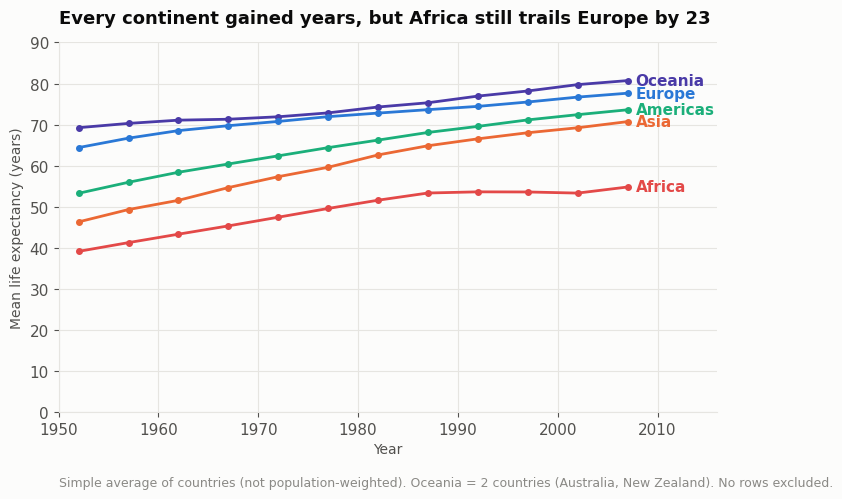

In [4]:
cont = g.groupby(["continent", "year"]).lifeExp.mean().unstack(0)
colours = dict(zip(["Oceania", "Europe", "Americas", "Asia", "Africa"], [VIOLET, BLUE, AQUA, ORANGE, RED]))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for c in colours:
    ax.plot(cont.index, cont[c], color=colours[c], marker="o", markersize=4)
    ax.text(2007 + 0.8, cont[c].iloc[-1], c, color=colours[c], va="center", fontweight="bold")
ax.set_xlim(1950, 2016); ax.set_ylim(0, 90)
ax.set_title("Every continent gained years, but Africa still trails Europe by 23")
ax.set_ylabel("Mean life expectancy (years)"); ax.set_xlabel("Year")
note(ax, "Simple average of countries (not population-weighted). Oceania = 2 countries (Australia, New Zealand). No rows excluded.")
save(fig, "t2_2a_continents")
plt.show()

## 2b. Highlight: all 142 lines, 3 picked out
Picked these three for the story they each tell:
- Rwanda — the 1994 genocide shows up as a cliff, life expectancy drops to about 24 at the 1992 data point.
- China — the biggest overall gain, 44 to 73 years, though there's a dip around 1962 worth noting.
- Botswana — climbed steadily until 1987, then lost about 17 years by 2002 as HIV/AIDS spread.

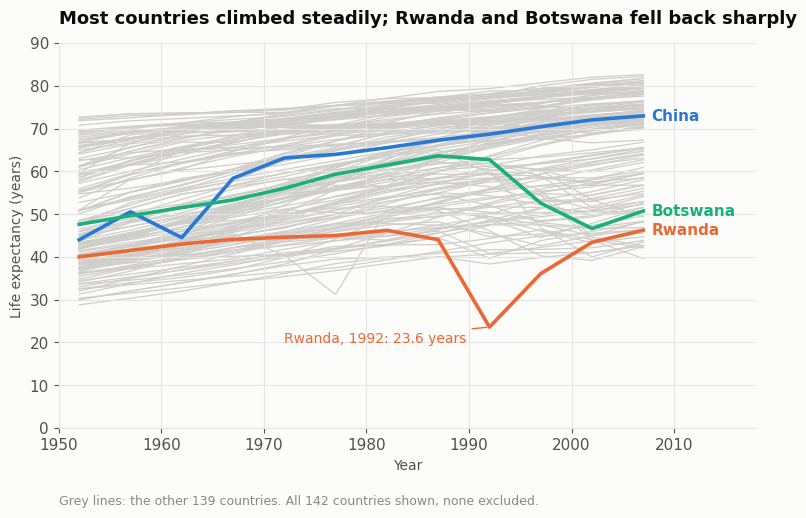

In [5]:
picks = {"Rwanda": ORANGE, "China": BLUE, "Botswana": AQUA}

fig, ax = plt.subplots(figsize=(9, 5))
for country, d in g.groupby("country"):
    if country not in picks:
        ax.plot(d.year, d.lifeExp, color=QUIET, linewidth=0.9, zorder=1)
for country, colour in picks.items():
    d = g[g.country == country]
    ax.plot(d.year, d.lifeExp, color=colour, linewidth=2.6, zorder=3)
    ax.text(2007 + 0.8, d.lifeExp.iloc[-1], country, color=colour, va="center", fontweight="bold")
ax.annotate("Rwanda, 1992: 23.6 years", (1992, 23.6), xytext=(1972, 20), color=ORANGE,
            arrowprops=dict(arrowstyle="-", color=ORANGE), fontsize=10)
ax.set_xlim(1950, 2018); ax.set_ylim(0, 90)
ax.set_title("Most countries climbed steadily; Rwanda and Botswana fell back sharply")
ax.set_ylabel("Life expectancy (years)"); ax.set_xlabel("Year")
note(ax, "Grey lines: the other 139 countries. All 142 countries shown, none excluded.")
save(fig, "t2_2b_highlight")
plt.show()

## 3. (a) vs (b)
The aggregate chart is good at showing the typical path for a region and how regions rank against each other — Africa trails the rest the whole way, Oceania leads. What it can't show is anything happening inside a continent: Botswana's reversal and Rwanda's crash both get smoothed away into Africa's average line, which barely dips.

The highlight chart does the opposite. It shows individual stories and how unusual they are against the backdrop of everyone else, but it can't say anything about continents as groups — the three colours are just my picks, not a category, and the grey mass behind them is too dense to read any pattern out of.

Also worth flagging: the aggregate chart's risk is that an unweighted mean can mislead (Oceania is only Australia and New Zealand), and the highlight chart's risk is selection bias — I chose the three most dramatic countries, which isn't a representative sample of anything.

Basically they're answering different questions. (a) answers "how do regions compare", (b) answers "how unusual is this particular country's story".

## 4. Checking the skew in gdpPercap
Before I compare rich and poor countries I want to see how GDP per capita is actually distributed.

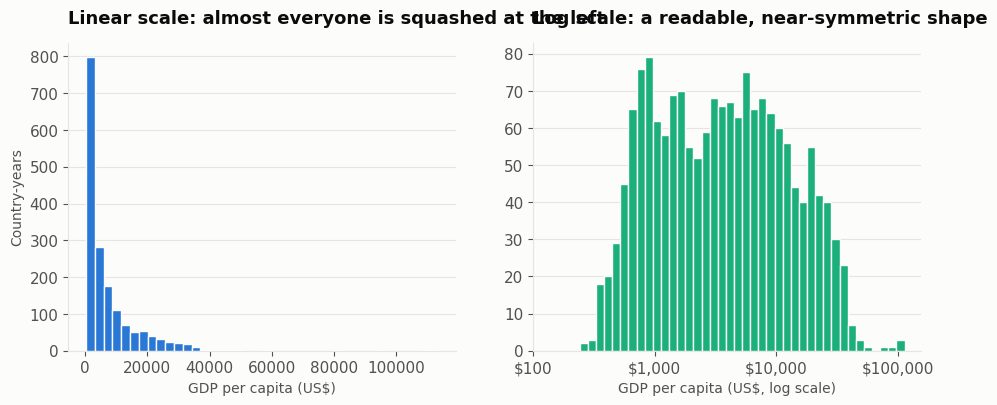

Skewness  linear: 3.85 | log10: 0.11


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(g.gdpPercap, bins=40, color=BLUE, edgecolor=SURFACE, zorder=3)
axes[0].set_title("Linear scale: almost everyone is squashed at the left")
axes[0].set_xlabel("GDP per capita (US$)"); axes[0].set_ylabel("Country-years")
axes[1].hist(np.log10(g.gdpPercap), bins=40, color=AQUA, edgecolor=SURFACE, zorder=3)
axes[1].set_xticks([2, 3, 4, 5]); axes[1].set_xticklabels(["$100", "$1,000", "$10,000", "$100,000"])
axes[1].set_title("Log scale: a readable, near-symmetric shape")
axes[1].set_xlabel("GDP per capita (US$, log scale)")
for a in axes: a.set_axisbelow(True); a.xaxis.grid(False)
save(fig, "t2_4_gdp_hist")
plt.show()
print("Skewness  linear:", round(g.gdpPercap.skew(), 2), "| log10:", round(np.log10(g.gdpPercap).skew(), 2))

A log scale multiplies by a fixed amount per step instead of adding one, so $500 to $5,000 takes up the same space as $5,000 to $50,000. That's why the linear histogram is so lopsided (skewness around 3.9) — a handful of very rich country-years up near $113k stretch the whole axis out — and why the log version looks much closer to symmetric (skewness drops to about 0.1).

For the distribution chart I'll go with the log scale. For the final chart below I actually skip a log axis entirely and just plot a ratio instead, which is already a multiplicative measure and reads honestly without needing a log transform.

## 5. Has the rich-poor gap narrowed since 1952?
Going with a line chart of the rich-to-poor ratio. Year is ordered so a line fits, and the question really comes down to one number — how many times richer the top group is than the bottom group, tracked over time. I'm defining "richest" and "poorest" as the top and bottom fifth of countries by GDP per capita, recalculated separately in each year (28 countries each).

Why a ratio instead of raw dollars: the dollar gap will grow just because everyone's getting richer, that's not interesting by itself. A ratio tells you whether the poor are catching up *proportionally*. I'll still report the dollar gap below so it's not hidden.

In [7]:
def quintile_means(d):
    d = d.sort_values("gdpPercap")
    n = round(len(d) / 5)
    return pd.Series({"poorest_fifth": d.gdpPercap.iloc[:n].mean(), "richest_fifth": d.gdpPercap.iloc[-n:].mean()})

gap = g.groupby("year").apply(quintile_means, include_groups=False)
gap["ratio"] = gap.richest_fifth / gap.poorest_fifth
gap["dollar_gap"] = gap.richest_fifth - gap.poorest_fifth
gap.round(1)

,poorest_fifth,richest_fifth,ratio,dollar_gap
year,,,,
1952,506.3,11687.2,23.1,11180.8
1957,557.8,13321.5,23.9,12763.7
1962,603.0,14166.9,23.5,13563.9
1967,659.6,16105.7,24.4,15446.2
1972,702.5,20083.3,28.6,19380.8
1977,719.5,20767.1,28.9,20047.6
1982,730.7,20720.7,28.4,19990.1
1987,714.2,22460.8,31.4,21746.6
1992,717.0,24390.0,34.0,23673.0


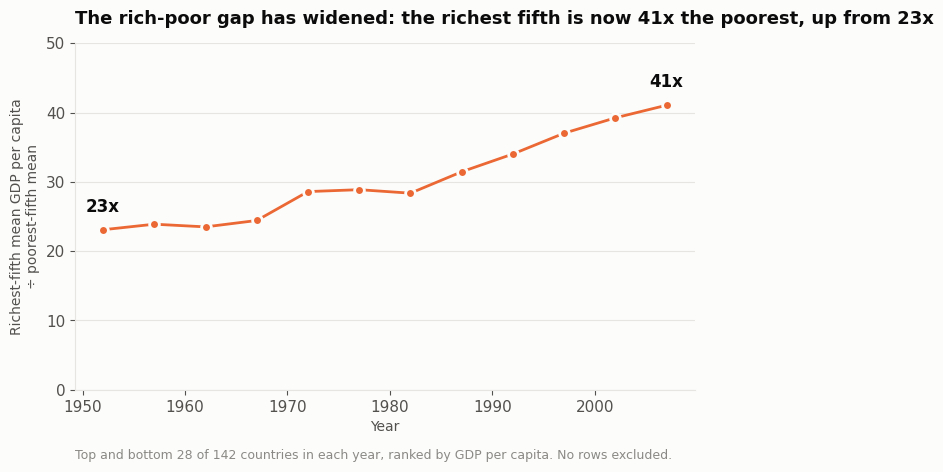

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(gap.index, gap.ratio, color=ORANGE, marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
for yr in (1952, 2007):
    ax.annotate(f"{gap.ratio[yr]:.0f}x", (yr, gap.ratio[yr]), textcoords="offset points",
                xytext=(0, 13), ha="center", fontsize=12, fontweight="bold", color=INK)
ax.set_ylim(0, 50)
ax.set_title("The rich-poor gap has widened: the richest fifth is now 41x the poorest, up from 23x")
ax.title.set_fontsize(12)
ax.set_ylabel("Richest-fifth mean GDP per capita\n÷ poorest-fifth mean"); ax.set_xlabel("Year")
ax.xaxis.grid(False)
note(ax, "Top and bottom 28 of 142 countries in each year, ranked by GDP per capita. No rows excluded.")
save(fig, "t2_5_gap_ratio")
plt.show()

No — it's widened, not narrowed. The ratio goes from about 23x in 1952 to about 41x in 2007, and the dollar gap grows from roughly $11,200 to $33,700 per person. The poorest fifth did get richer too (about $506 to $842), just nowhere near as fast as the top.

Two caveats worth keeping in mind. First, the top and bottom groups get re-picked every year, so it's not literally the same 28 countries the whole way through. Second, this is income specifically — if you ran the same test on life expectancy instead, the gap barely moves, staying in a 24-29 year band the whole period. So the answer really depends on which measure the question is actually about.